In [56]:
import os, sys
import numpy as np
import scipy.constants as sc

def isovelocity_curves(M_star=1.0, incl=45., PA=90., V_sys=0., distance=140., Ngrid=512, Rgrid=1024):
    
    # Constants (using SI / MKS units)
    M_sun = 1.989e30
    
    # Convert projection angles to radians
    incl_r = np.radians(incl)
    pa_r = np.radians(PA)
    
    # Sky-plane grid, defined in arcsecond offsets
    x_arcsec = np.linspace(-Rgrid / distance, Rgrid / distance, Ngrid)
    y_arcsec = np.linspace(-Rgrid / distance, Rgrid / distance, Ngrid)
    X_sky, Y_sky = np.meshgrid(x_arcsec, y_arcsec)
    
    # Rotate to account for PA (aligns the coordinates so X_disk is along the projected major axis)
    X_rot =  X_sky * np.sin(pa_r) + Y_sky * np.cos(pa_r)
    Y_rot = -X_sky * np.cos(pa_r) + Y_sky * np.sin(pa_r)
    
    # Deproject to the disk coordinate frame (physical distances -- in this case, in meters)
    X_disk = X_rot * distance * sc.au
    Y_disk = (Y_rot / np.cos(incl_r)) * distance * sc.au
    R_disk = np.sqrt(X_disk**2 + Y_disk**2)
    
    # Keplerian velocities (in m / s)
    with np.errstate(divide='ignore', invalid='ignore'):
        V_kep = np.sqrt((sc.G * M_star * M_sun) / R_disk)
        
    # project those velocities along the line of sight: V_los = V_sys + V_kep * sin(i) * cos(theta)
    # where theta is the azimuth angle in the disk frame, defined such that cos(theta) = X_disk / R_disk
    cos_theta = X_disk / R_disk
    V_los = V_sys + V_kep * np.sin(incl_r) * cos_theta
    
    # Mask out the very center or outside edge if necessary
    V_los[R_disk > (Rgrid * sc.au)] = np.nan
    
    return X_sky, Y_sky, V_los

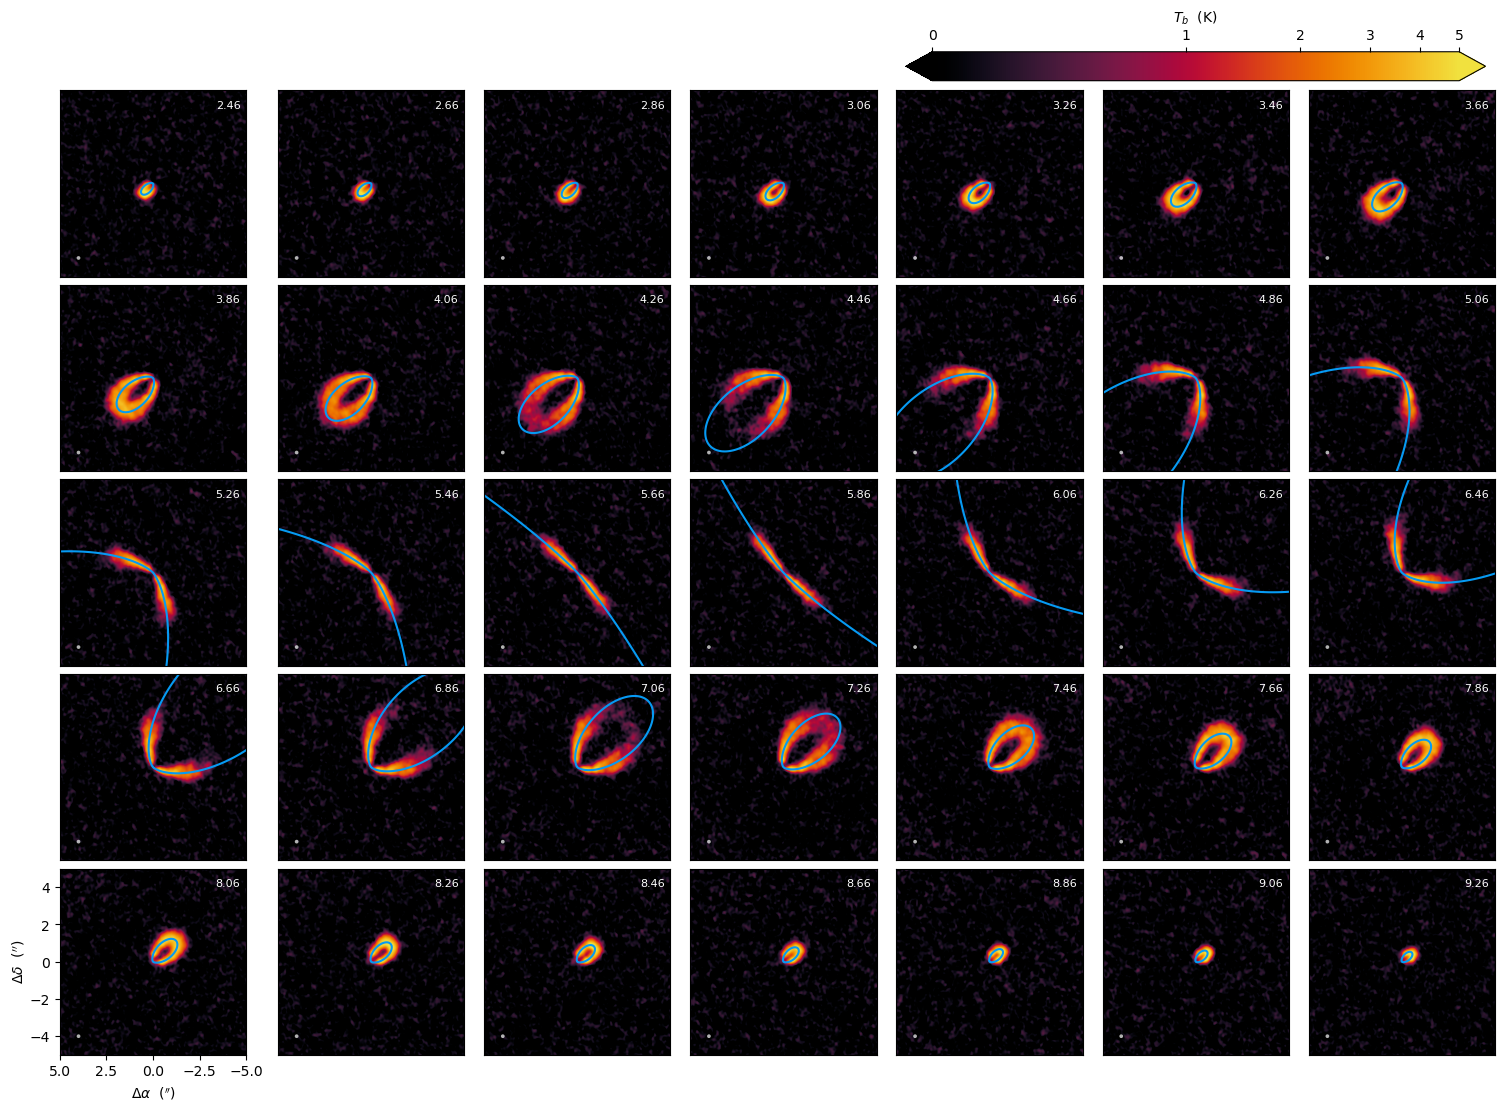

In [65]:
from astropy.io import fits
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from astropy.visualization import (AsinhStretch, LogStretch, ImageNormalize)
import cmasher as cmr


# cube FITS file
cube_fits = 'HD_163296_C18O_220GHz.0.2arcsec.JvMcorr.image.pbcor.fits'


# display properties
Tmin, Tmax = 0, 5     # min and max brightness temperature (in K)
nrows, ncols = 5, 7
nchans, ch0, dch = nrows * ncols, 79, -1
xlims = np.array([5, -5])
cm = 'cmr.ember'
norm = ImageNormalize(vmin=Tmin, vmax=Tmax, stretch=AsinhStretch())

fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 11), constrained_layout=True)

# load the cube and header
hdu = fits.open('/Users/seanandrews/Desktop/active projects/student projects/AY98_Mei/' + cube_fits)
Ico, hd = np.squeeze(hdu[0].data), hdu[0].header
hdu.close()

# define coordinate grids
dx = 3600 * hd['CDELT1'] * (np.arange(hd['NAXIS1']) - (hd['CRPIX1'] - 1))
dy = 3600 * hd['CDELT2'] * (np.arange(hd['NAXIS2']) - (hd['CRPIX1'] - 1))
ext = (np.max(dx), np.min(dx), np.min(dy), np.max(dy))

# define beam areas (and dimensions for imaged cases)
bm = np.abs(np.pi * hd['BMAJ'] * hd['BMIN'])*(np.pi/180)**2 


# set up a row of channel maps
for ir in range(nrows):

    # set up a column entry
    for ic in range(ncols):
        
        # assign the frequency index of the desired channel for this entry
        nu_ix = dch * (ir * ncols + ic) + ch0
        
        # calculate frequency and velocity for this channel
        nu_ = hd['CRVAL3'] + nu_ix * hd['CDELT3']
        V_ = sc.c * (1 - nu_ / hd['RESTFRQ'])
        
        # convert intensities into brightness temperatures (in Rayleigh-Jeans limit)
        Tb = (1e-26 * Ico[nu_ix,:,:] / bm) * sc.c**2 / (2 * sc.k * nu_**2)
        
        # plot the channel map image
        ax = axs[ir, ic]
        im = ax.imshow(Tb, origin='lower', cmap=cm, extent=ext, aspect='equal', norm=norm)
        
        # overplot isovelocity contour
        X, Y, V_los = isovelocity_curves(M_star=1.92, V_sys=5750, incl=46.7, PA=312.6, distance=101.)
        _ = ax.contour(X, Y, V_los, levels=[V_], colors='xkcd:azure')

        # mark the beam (resolution) dimensions
        beam = Ellipse((xlims[0] + 0.1 * np.diff(xlims), -xlims[0] - 0.1 * np.diff(xlims)),
                       3600 * hd['BMAJ'], 3600 * hd['BMIN'], angle=90 - hd['BPA'])
        beam.set_facecolor('w')
        beam.set_alpha(0.7)
        ax.add_artist(beam)

        # channel velocity labels (these are printed in km/s -- standard units for channel maps)
        if np.abs(V_) < 0.001: V_ = 0.0
        if np.logical_or(np.sign(v) == 1, np.sign(v) == 0):
            pref = '+'
        else: 
            pref = ''
        vstr = pref + '%.2f' % (1e-3 * V_)
        ax.text(0.97, 0.92, vstr, transform=ax.transAxes, ha='right', va='center', fontsize=8, color='w')

        # modify the axis limits and styling/annotation
        ax.set_xlim(xlims)
        ax.set_ylim(-xlims)
        if np.logical_and(ic == 0, ir == nrows - 1):
            ax.set_xlabel('$\Delta \\alpha$  ($^{\prime\prime}$)')
            ax.set_ylabel('$\Delta \\delta$  ($^{\prime\prime}$)', labelpad=2)
        else:
            ax.tick_params(axis='both', which='both', length=0)
            ax.set_xticklabels([])
            ax.set_yticklabels([])

# colorbar            
cbar = fig.colorbar(im, ax=axs[:,4:], location='top', shrink=0.95, pad=0.01, extend='both')  
cbar.set_label('$T_b$  (K)')